In [1]:
# 1. Kütüphanelerin içe aktarılması
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 2. Rastgelelik sabitleme (Tekrarlanabilirlik için)
SEED = 42
np.random.seed(SEED)

# 3. Görsel stil ve standartlaştırma
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# 4. Pandas görüntüleme ayarları
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# 5. 1000 Gözlemli Sentetik Veri Seti Oluşturma
n = 1000

yas = np.random.randint(18, 70, size=n).astype(float)
gelir = np.random.normal(loc=45000, scale=12000, size=n)
harcama = np.random.gamma(shape=2, scale=500, size=n)
memnuniyet = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.1, 0.15, 0.35, 0.25, 0.15]).astype(float)
churn = np.random.choice([0, 1], size=n, p=[0.78, 0.22])
abonelik = np.random.choice(["Temel", "Standart", "Premium"], size=n, p=[0.5, 0.3, 0.2])

# Tutarsız şehir yazımları simülasyonu
sehir_havuzu = ["İstanbul", "istanbul", "İSTANBUL ", "Ankara", "ankara", " ANKARA", "İzmir", "izmir", "Bursa"]
sehir = np.random.choice(sehir_havuzu, size=n)

tarihler = pd.date_range(start="2023-01-01", end="2024-01-01", periods=n)

df = pd.DataFrame({
    "yas": yas,
    "gelir": gelir,
    "aylik_harcama": harcama,
    "memnuniyet_puani": memnuniyet,
    "sehir": sehir,
    "abonelik_tipi": abonelik,
    "kayit_tarihi": tarihler,
    "churn": churn
})

# 6. Kasıtlı "Kirli Veri" Enjeksiyonu
# Eksik değerler (NaN)
df.loc[np.random.choice(df.index, size=60, replace=False), "gelir"] = np.nan
df.loc[np.random.choice(df.index, size=40, replace=False), "yas"] = np.nan
df.loc[np.random.choice(df.index, size=25, replace=False), "memnuniyet_puani"] = np.nan

# Aykırı değerler (Outliers) - Gelir
df.loc[np.random.choice(df.index, size=8, replace=False), "gelir"] = np.random.uniform(250000, 500000, size=8)

# Mantık dışı anomali değerler - Yaş
df.loc[np.random.choice(df.index, size=4, replace=False), "yas"] = np.array([-5, -1, 142, 160])

# Yinelenen (Duplicate) satırlar ekleme
df_duplicates = df.sample(n=15, random_state=SEED)
df = pd.concat([df, df_duplicates], ignore_index=True)

print(f"Oluşturulan veri boyutu: {df.shape}")

Oluşturulan veri boyutu: (1015, 8)


Bölüm 2: Veri Setine Genel Bakış, Eksik Değer ve Çift Kayıt Analizi

--- Sütun ve Veri Tipi Özeti ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   yas               975 non-null    float64       
 1   gelir             955 non-null    float64       
 2   aylik_harcama     1015 non-null   float64       
 3   memnuniyet_puani  989 non-null    float64       
 4   sehir             1015 non-null   object        
 5   abonelik_tipi     1015 non-null   object        
 6   kayit_tarihi      1015 non-null   datetime64[ns]
 7   churn             1015 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 63.6+ KB

--- İlk 3 Satır ---


,yas,gelir,aylik_harcama,memnuniyet_puani,sehir,abonelik_tipi,kayit_tarihi,churn
0,56.00,25722.64,2519.03,3.00,İzmir,Temel,2023-01-01 00:00:00.000000000,0
1,69.00,47441.56,601.07,1.00,İSTANBUL,Temel,2023-01-01 08:46:07.567567567,1
2,46.00,NaN,212.15,1.00,Ankara,Temel,2023-01-01 17:32:15.135135135,0



--- Son 3 Satır ---


,yas,gelir,aylik_harcama,memnuniyet_puani,sehir,abonelik_tipi,kayit_tarihi,churn
1012,66.00,47413.19,215.48,1.00,İzmir,Temel,2023-08-21 08:56:12.972972972,0
1013,66.00,NaN,1324.17,3.00,İzmir,Temel,2023-12-22 12:00:43.243243244,0
1014,68.00,51459.55,1560.13,5.00,İstanbul,Standart,2023-12-09 17:06:18.378378376,0



--- Rastgele 3 Satır ---


,yas,gelir,aylik_harcama,memnuniyet_puani,sehir,abonelik_tipi,kayit_tarihi,churn
752,66.00,35355.91,1186.32,4.00,İstanbul,Premium,2023-10-02 18:06:50.810810808,1
519,63.00,56095.60,725.78,5.00,ankara,Temel,2023-07-09 14:59:27.567567566,0
210,32.00,32027.24,595.29,1.00,İzmir,Premium,2023-03-18 17:26:29.189189189,0



Birebir aynı satır sayısı: 15

--- Eksik Değer Özeti ---


,Eksik_Sayi,Eksik_Yuzde(%),Benzersiz_Deger
gelir,60,5.91,941
yas,40,3.94,56
memnuniyet_puani,26,2.56,5
aylik_harcama,0,0.00,1000
sehir,0,0.00,9
abonelik_tipi,0,0.00,3
kayit_tarihi,0,0.00,1000
churn,0,0.00,2


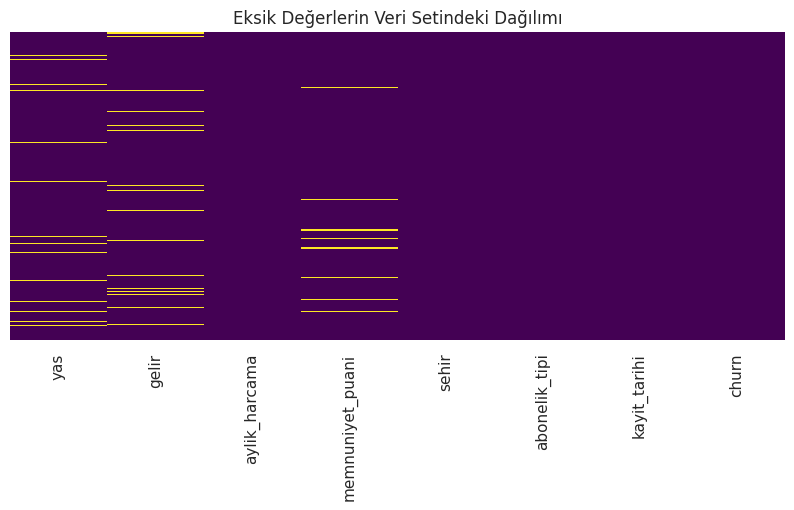

In [2]:
# 1. Boyut ve genel yapı
print("--- Sütun ve Veri Tipi Özeti ---")
df.info()

print("\n--- İlk 3 Satır ---")
display(df.head(3))

print("\n--- Son 3 Satır ---")
display(df.tail(3))

print("\n--- Rastgele 3 Satır ---")
display(df.sample(3, random_state=SEED))

# 2. Yinelenen (Duplicate) Satır Analizi
duplicate_sayisi = df.duplicated().sum()
print(f"\nBirebir aynı satır sayısı: {duplicate_sayisi}")

# 3. Eksik Değer Analiz Tablosu
eksik_sayi = df.isnull().sum()
eksik_oran = (df.isnull().sum() / len(df)) * 100
benzersiz = df.nunique()

eksik_ozet = pd.DataFrame({
    "Eksik_Sayi": eksik_sayi,
    "Eksik_Yuzde(%)": eksik_oran,
    "Benzersiz_Deger": benzersiz
}).sort_values(by="Eksik_Sayi", ascending=False)

print("\n--- Eksik Değer Özeti ---")
display(eksik_ozet)

# 4. Eksik Değer Isı Haritası (Heatmap)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Eksik Değerlerin Veri Setindeki Dağılımı")
plt.show()

Bölüm 3: Kategorik Temizlik ve Anomali Tespiti

In [3]:
# 1. Şehir sütunundaki yazım tutarsızlıkları
print("--- Temizlik Öncesi Şehir Dağılımı ---")
print(df["sehir"].value_counts())

# Şehir isimlerini standartlaştırma (küçük harf + baştaki/sondaki boşlukları silme)
df["sehir_temiz"] = df["sehir"].str.strip().str.lower()

# Türkçe karakter düzenlemesi (isteğe bağlı tam standartlık)
df["sehir_temiz"] = df["sehir_temiz"].str.replace("i̇", "i")

print("\n--- Temizlik Sonrası Şehir Dağılımı ---")
print(df["sehir_temiz"].value_counts())

# 2. Mantık dışı Yaş değerlerinin tespiti (< 0 veya > 100)
hatali_yaslar = df[(df["yas"] < 0) | (df["yas"] > 100)]
print(f"\nMantıksız Yaş Değeri İçeren Satır Sayısı: {len(hatali_yaslar)}")
display(hatali_yaslar[["yas", "gelir", "sehir_temiz"]])

--- Temizlik Öncesi Şehir Dağılımı ---
sehir
İstanbul     138
Bursa        124
İzmir        118
İSTANBUL     116
 ANKARA      112
Ankara       110
istanbul     103
izmir         99
ankara        95
Name: count, dtype: int64

--- Temizlik Sonrası Şehir Dağılımı ---
sehir_temiz
istanbul    357
ankara      317
izmir       217
bursa       124
Name: count, dtype: int64

Mantıksız Yaş Değeri İçeren Satır Sayısı: 4


,yas,gelir,sehir_temiz
26,160.00,45582.26,istanbul
376,-5.00,38373.32,bursa
644,-1.00,48631.63,istanbul
905,142.00,63738.13,istanbul


Bölüm 4: Betimsel İstatistikler ve Dağılım Grafikleri

--- Temel İstatistiksel Özet ---


,count,mean,std,min,25%,50%,75%,max
yas,975.00,44.20,15.89,-5.00,31.00,44.00,56.00,160.00
gelir,955.00,48435.15,28551.04,10244.94,38103.97,46277.16,53805.11,419994.64
aylik_harcama,1015.00,1024.49,714.51,12.93,496.37,871.99,1359.13,6805.12



--- Çarpıklık ve Basıklık Değerleri ---


,Skewness (Çarpıklık),Kurtosis (Basıklık)
yas,0.51,3.04
gelir,8.64,92.36
aylik_harcama,1.53,5.14


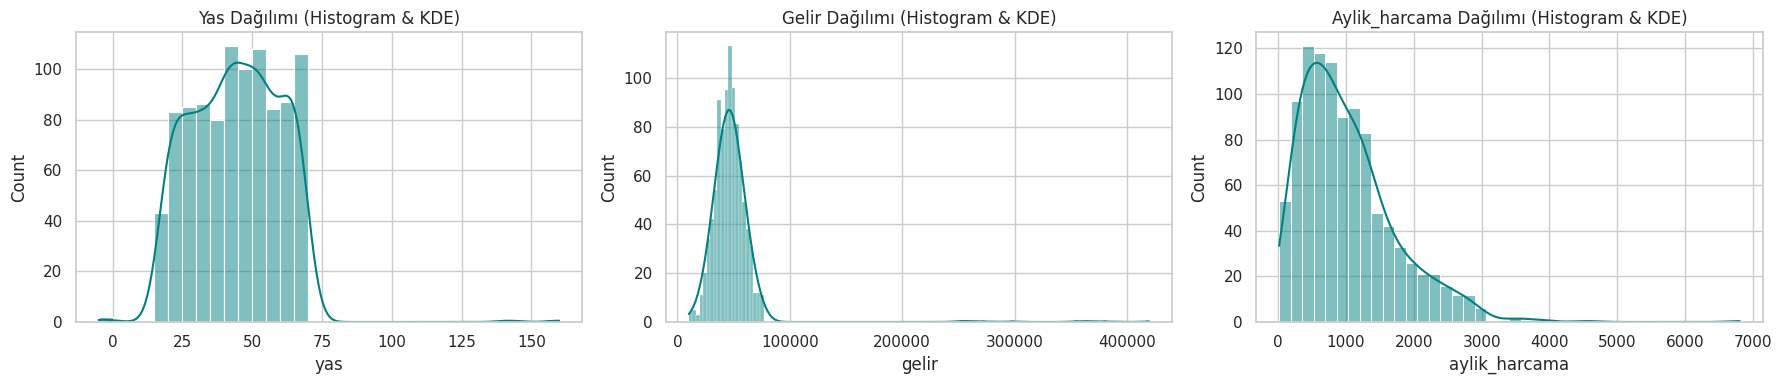

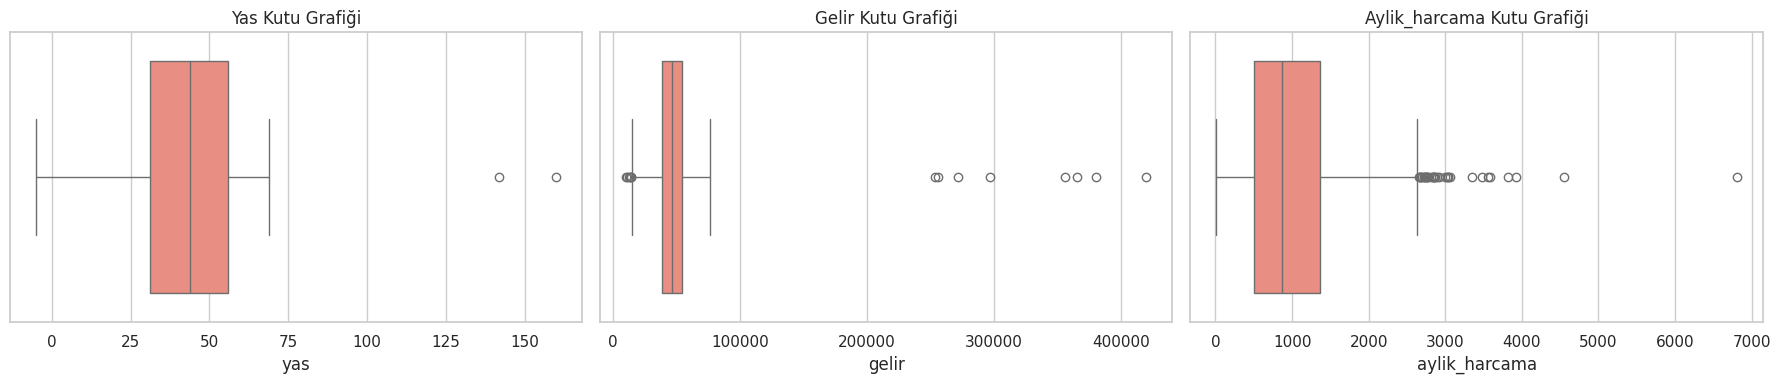

In [4]:
# 1. Sayısal değişkenler için özet istatistikler
sayisal_kolonlar = ["yas", "gelir", "aylik_harcama"]

print("--- Temel İstatistiksel Özet ---")
display(df[sayisal_kolonlar].describe().T)

# 2. Çarpıklık (Skewness) ve Basıklık (Kurtosis)
carpiklik_basiklik = pd.DataFrame({
    "Skewness (Çarpıklık)": df[sayisal_kolonlar].skew(),
    "Kurtosis (Basıklık)": df[sayisal_kolonlar].kurtosis()
})
print("\n--- Çarpıklık ve Basıklık Değerleri ---")
display(carpiklik_basiklik)

# 3. Histogram ve KDE Dağılımları
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(sayisal_kolonlar):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"{col.capitalize()} Dağılımı (Histogram & KDE)")
plt.tight_layout()
plt.show()

# 4. Kutu Grafiği (Boxplot) ile Aykırı Değer İncelemesi
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(sayisal_kolonlar):
    sns.boxplot(x=df[col], ax=axes[i], color="salmon")
    axes[i].set_title(f"{col.capitalize()} Kutu Grafiği")
plt.tight_layout()
plt.show()

Bölüm 5: Kategorik Dağılım ve Korelasyon Analizi

--- Kategorik Değişkenlerin Yüzdesel Dağılımı ---

Değişken: sehir_temiz


,Frekans,Yüzde (%)
sehir_temiz,,
istanbul,357,35.17
ankara,317,31.23
izmir,217,21.38
bursa,124,12.22



Değişken: abonelik_tipi


,Frekans,Yüzde (%)
abonelik_tipi,,
Temel,514,50.64
Standart,291,28.67
Premium,210,20.69



Değişken: memnuniyet_puani


,Frekans,Yüzde (%)
memnuniyet_puani,,
3.00,357,35.17
4.00,238,23.45
2.00,152,14.98
5.00,143,14.09
1.00,99,9.75
NaN,26,2.56



Değişken: churn


,Frekans,Yüzde (%)
churn,,
0,792,78.03
1,223,21.97



--- Korelasyon Matrisi ---


,yas,gelir,aylik_harcama,memnuniyet_puani,churn
yas,1.00,0.01,0.00,0.01,-0.01
gelir,0.01,1.00,0.01,-0.04,0.08
aylik_harcama,0.00,0.01,1.00,0.05,-0.02
memnuniyet_puani,0.01,-0.04,0.05,1.00,-0.03
churn,-0.01,0.08,-0.02,-0.03,1.00


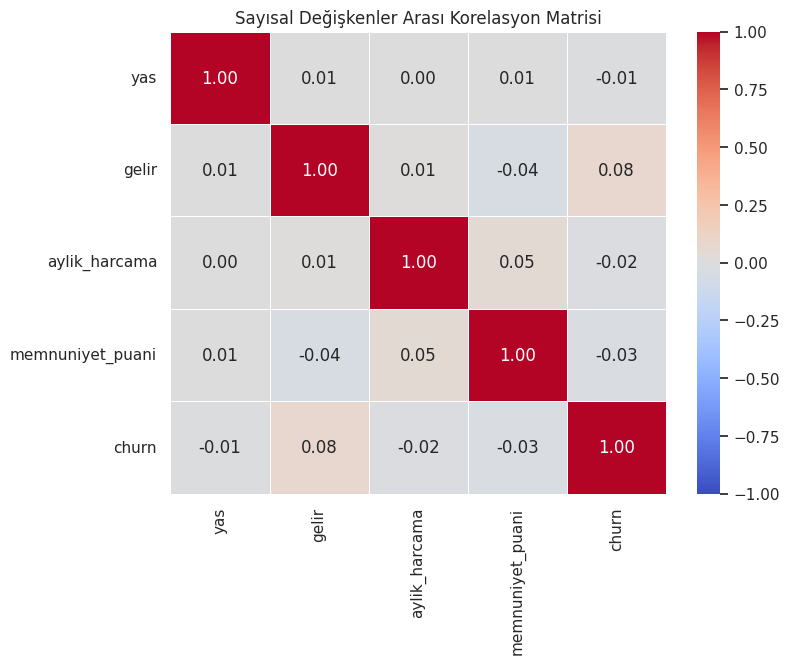

In [5]:
# 1. Kategorik sütunların yüzdesel dağılımı
kategorik_kolonlar = ["sehir_temiz", "abonelik_tipi", "memnuniyet_puani", "churn"]

print("--- Kategorik Değişkenlerin Yüzdesel Dağılımı ---")
for col in kategorik_kolonlar:
    yuzde = df[col].value_counts(normalize=True, dropna=False) * 100
    dagilim_df = pd.DataFrame({"Frekans": df[col].value_counts(dropna=False), "Yüzde (%)": yuzde})
    print(f"\nDeğişken: {col}")
    display(dagilim_df)

# 2. Korelasyon Matrisi ve Isı Haritası
korelasyon_kolonlari = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani", "churn"]
corr_matrix = df[korelasyon_kolonlari].corr()

print("\n--- Korelasyon Matrisi ---")
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Sayısal Değişkenler Arası Korelasyon Matrisi")
plt.show()